# BEE 4750 Lab 2: Monte Carlo

**Name**: Emma Pereira

**ID**: ejp99

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `c:\Users\emmaj\OneDrive\Desktop\4750HW\lab-2-ejadee`
   Installed Xorg_libXfixes_jll ─────── v6.0.2+0
   Installed Pango_jll ──────────────── v1.56.4+0
   Installed Libuuid_jll ────────────── v2.41.2+0
   Installed Libmount_jll ───────────── v2.41.2+0
   Installed Libtiff_jll ────────────── v4.7.2+0
   Installed Xorg_xcb_util_cursor_jll ─ v0.1.6+0
   Installed FillArrays ─────────────── v1.14.0
   Installed Plots ──────────────────── v1.41.1
   Installed ColorSchemes ───────────── v3.31.0
Precompiling project...
   8916.9 ms  ✓ Libmount_jll
   8677.9 ms  ✓ Rmath_jll
   5625.9 ms  ✓ OpenSpecFun_jll
   4868.3 ms  ✓ QuadGK
   9908.4 ms  ✓ FillArrays
   1670.3 ms  ✓ Libuuid_jll
   1626.7 ms  ✓ Xorg_libXfixes_jll
   1743.3 ms  ✓ Xorg_xcb_util_cursor_jll
   2665.0 ms  ✓ Libtiff_jll
   1389.7 ms  ✓ FillArrays → FillArraysStatisticsExt
   2181.6 ms  ✓ Rmath
   1836.3 ms  ✓ FillArrays → FillArraysPDMatsExt
   2588.7 ms  ✓ FillArrays → FillArraysSparseArraysExt
   2213.6

In [2]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [3]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [4]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

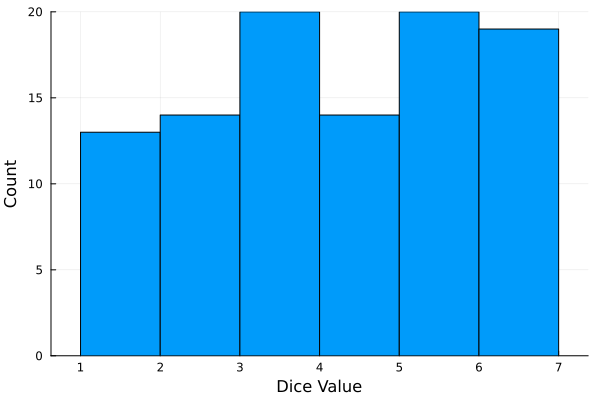

In [5]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

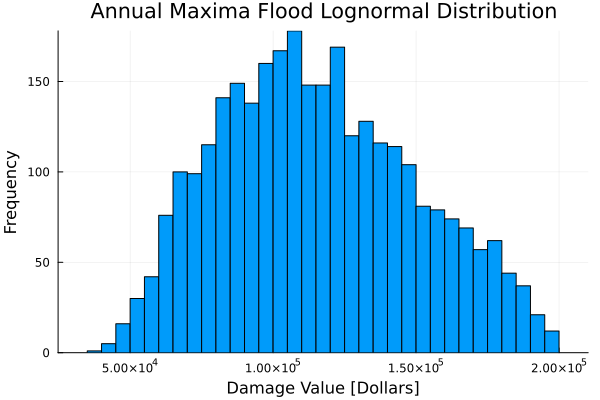

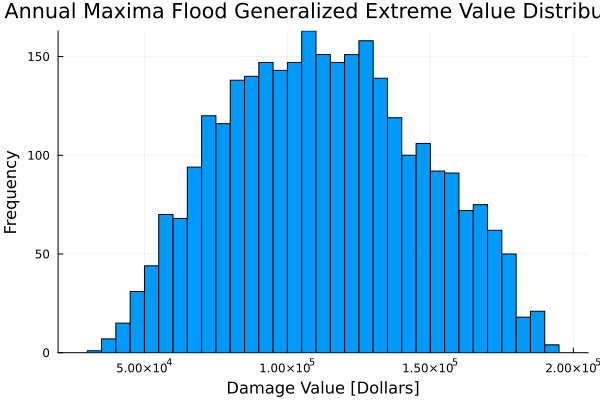

The mean of the lognormal distribution damage values are $115629
The mean od the generalized extreme value distribution damage values are $112832
The 99% quantile for maximum damage for the lognormal distribution is $190694
The 99% quantile for maximum damage for the generalized extreme value distribution is $183779


In [68]:
#Constants
L = 200000
k = 0.8
ho = 3

#determine indicator function
function give_x(h)
    if h > 0
        return 1
    else
       return 0
    end
end

#define depth equation
function depth_damage(h, x, L, k, ho)
    return x*L*(1/ (1 + exp(-k * (h - ho))))
end

#define distribution
function histy(L, k, ho, samp)
    h1 = rand(LogNormal(1.2, 0.3), samp)
    h2 = rand(GeneralizedExtremeValue(3, 0.9, -0.15), samp)

    samps1 = zeros(samp)
    for i = 1:samp
        samps1[i] = depth_damage(h1[i], give_x(h1[i]), L, k, ho)
    end

    samps2 = zeros(samp)
    for i = 1:samp
        samps2[i] = depth_damage(h2[i], give_x(h2[i]), L, k, ho)
    end

    p1 = histogram(samps1, label = false, title = "Annual Maxima Flood Lognormal Distribution", bins = 50, xlabel = "Damage Value [Dollars]", ylabel = "Frequency")
    p2 = histogram(samps2, label = false, title = "Annual Maxima Flood Generalized Extreme Value Distribution", bins = 50, xlabel = "Damage Value [Dollars]", ylabel = "Frequency")
    display(p1)
    display(p2)

    println("The mean of the lognormal distribution damage values are \$", round(Int, mean(samps1)))
    println("The mean od the generalized extreme value distribution damage values are \$", round(Int, mean(samps2)))

    println("The 99% quantile for maximum damage for the lognormal distribution is \$", round(Int, quantile!(samps1, 0.99)))
    println("The 99% quantile for maximum damage for the generalized extreme value distribution is \$", round(Int, quantile!(samps2, 0.99)))
end

samp = 3000 #Begins convergence at around 3000
histy(L, k, ho, samp)

#### Write Up

1. The mean and max value of the lognormal distribution was ~$11500 and $190000, respectvely. For the generalized extreme value distribution, it was $11300 and $184000,        respectively.
2. I chose a sample size of 3000 after I tested a large sample to size to see where the values would converge to, and the lowest sample size where this convergence happened was at arround 3000.
3. From my results, I found that the Lognormal distribution had overall higher values for damage from the flood when compared to the generalized extreme value distribution. This difference may be due to the different behaviors of the distributions themselves. The GEV distribution takes into account any extreme values that may happen, thus leading to its shape being more flexible in nature, while the lognormal distribution nomalizing the data may lead outliers of extreme values to affect the curve in a nagative manner.
4. When it comes to choosing which distribution to use, it would depend on what type of flood risks measurments I am making. If I am accounting for flood that occur in similar intensity and have a low history of data, I would pick the lognormal distribution. If I am accouting for a longer history of mroe randomized flood intensities (with many extreme values), I would pick the GEV distribution.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

Pranati and Adrian helped me with my code.